# Importing the libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Data Reading and Understanding

In [2]:
#Loading the titanic dataset
df = pd.read_csv("train.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
#Knowing the size of the dataset
print(f"The shape of the dataset : {df.shape}")

The shape of the dataset : (891, 12)


In [4]:
df.sample(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
634,635,0,3,"Skoog, Miss. Mabel",female,9.0,3,2,347088,27.9000,NaN,S
146,147,1,3,"Andersson, Mr. August Edvard (""Wennerstrom"")",male,27.0,0,0,350043,7.7958,NaN,S
828,829,1,3,"McCormack, Mr. Thomas Joseph",male,NaN,0,0,367228,7.7500,NaN,Q
73,74,0,3,"Chronopoulos, Mr. Apostolos",male,26.0,1,0,2680,14.4542,NaN,C
364,365,0,3,"O'Brien, Mr. Thomas",male,NaN,1,0,370365,15.5000,NaN,Q


In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
PassengerId,891.0,446.000000,257.353842,1.00,223.5000,446.0000,668.5,891.0000
Survived,891.0,0.383838,0.486592,0.00,0.0000,0.0000,1.0,1.0000
Pclass,891.0,2.308642,0.836071,1.00,2.0000,3.0000,3.0,3.0000
Age,714.0,29.699118,14.526497,0.42,20.1250,28.0000,38.0,80.0000
SibSp,891.0,0.523008,1.102743,0.00,0.0000,0.0000,1.0,8.0000
Parch,891.0,0.381594,0.806057,0.00,0.0000,0.0000,0.0,6.0000
Fare,891.0,32.204208,49.693429,0.00,7.9104,14.4542,31.0,512.3292


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [7]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [8]:
#This method is easier to understand the amount of missing values in a column
df.isna().sum().sort_values(ascending=False)/df.shape[0] * 100

Cabin          77.104377
Age            19.865320
Embarked        0.224467
PassengerId     0.000000
Survived        0.000000
Pclass          0.000000
Name            0.000000
Sex             0.000000
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.000000
dtype: float64

In [9]:
df.duplicated().sum()

np.int64(0)

# Data Preprocessing and Feature engineering

In [10]:
# Getting the titles from the names
df['Title'] = [df['Name'][i].split(',')[1].split('.')[0].strip() for i in range(df.shape[0])]
df['Title'].value_counts()

Title
Mr              517
Miss            182
Mrs             125
Master           40
Dr                7
Rev               6
Mlle              2
Major             2
Col               2
the Countess      1
Capt              1
Ms                1
Sir               1
Lady              1
Mme               1
Don               1
Jonkheer          1
Name: count, dtype: int64

In [11]:
# Mapping rare titles to more frequent ones
title_mapping = {
    'Mr': 'Mr',
    'Miss': 'Miss',
    'Mrs': 'Mrs',
    'Master': 'Master',
    'Mlle': 'Miss',
    'Ms': 'Miss',
    'Mme': 'Mrs',
    'Dr': 'Rare',
    'Rev': 'Rare',
    'Col': 'Rare',
    'Major': 'Rare',
    'Capt': 'Rare',    
    'Don': 'Rare',
    'Lady': 'Rare',
    'Sir': 'Rare',
    'the Countess': 'Rare',
    'Jonkheer': 'Rare'
}

df['Title'] = df['Title'].map(title_mapping)
df['Title'].value_counts()

Title
Mr        517
Miss      185
Mrs       126
Master     40
Rare       23
Name: count, dtype: int64

In [12]:
# Adding 2 important feature
df["Family_size"] = df["SibSp"] + df["Parch"] + 1
df["Is_alone"] = (df["Family_size"]==1).astype(int)

In [13]:
# Droping unnecessary columns
un_cols = ['PassengerId','Name','Ticket','SibSp','Parch']
df.drop(un_cols, axis = 1 , inplace=True)

In [14]:
# Handling the null values
# Cabin has more than 77% of null values
df.drop('Cabin', axis=1, inplace=True)

In [15]:
df["Age"] = df.groupby('Title')['Age'].transform(lambda x : x.fillna(x.median()))

In [16]:
# Filling the missing embarked value with the mode
df["Embarked"] = df["Embarked"].fillna(df['Embarked'].mode()[0])

In [17]:
df.head()

,Survived,Pclass,Sex,Age,Fare,Embarked,Title,Family_size,Is_alone
0,0,3,male,22.0,7.2500,S,Mr,2,0
1,1,1,female,38.0,71.2833,C,Mrs,2,0
2,1,3,female,26.0,7.9250,S,Miss,1,1
3,1,1,female,35.0,53.1000,S,Mrs,2,0
4,0,3,male,35.0,8.0500,S,Mr,1,1


In [18]:
df.isna().sum().sort_values(ascending = False) / df.shape[0] * 100

Survived       0.0
Pclass         0.0
Sex            0.0
Age            0.0
Fare           0.0
Embarked       0.0
Title          0.0
Family_size    0.0
Is_alone       0.0
dtype: float64

# Data Visualization

[]

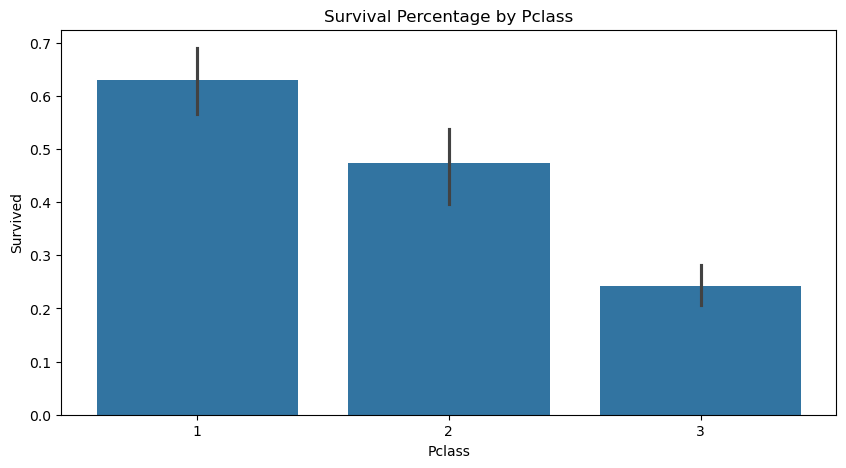

In [19]:
plt.figure(figsize=(10,5))
sns.barplot(x=df['Pclass'],y=df['Survived'])
plt.title("Survival Percentage by Pclass")
plt.plot()

[]

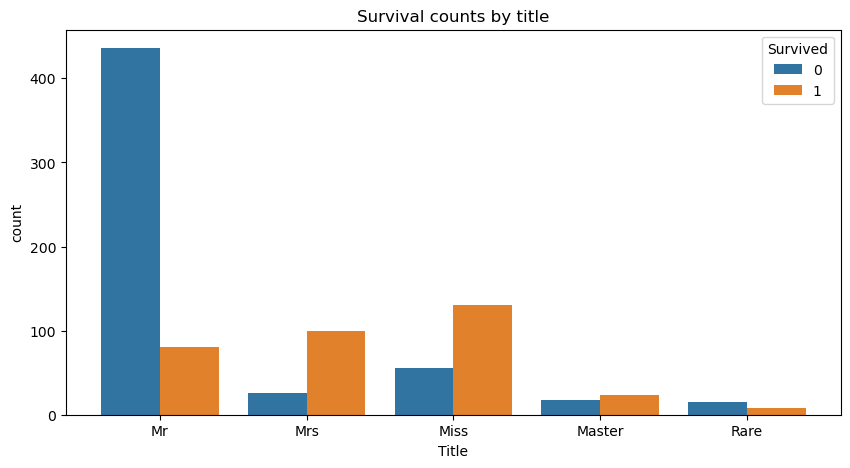

In [20]:
plt.figure(figsize=(10,5))
sns.countplot(x=df['Title'], hue=df['Survived'])
plt.title("Survival counts by title")
plt.plot()

[]

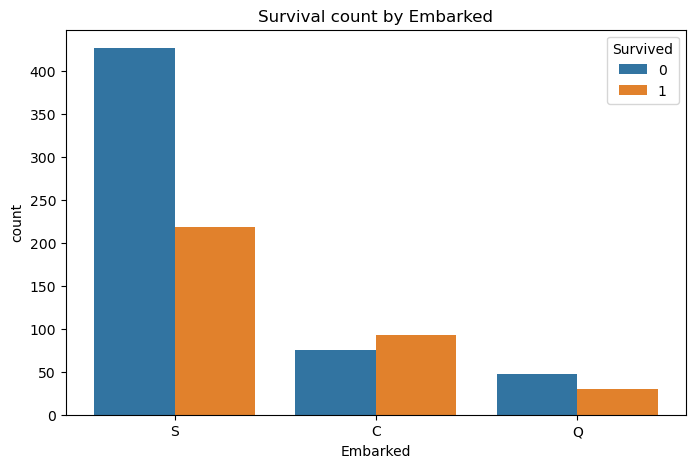

In [21]:
plt.figure(figsize=(8,5))
sns.countplot(x=df['Embarked'], hue = df['Survived'])
plt.title('Survival count by Embarked')
plt.plot()

[]

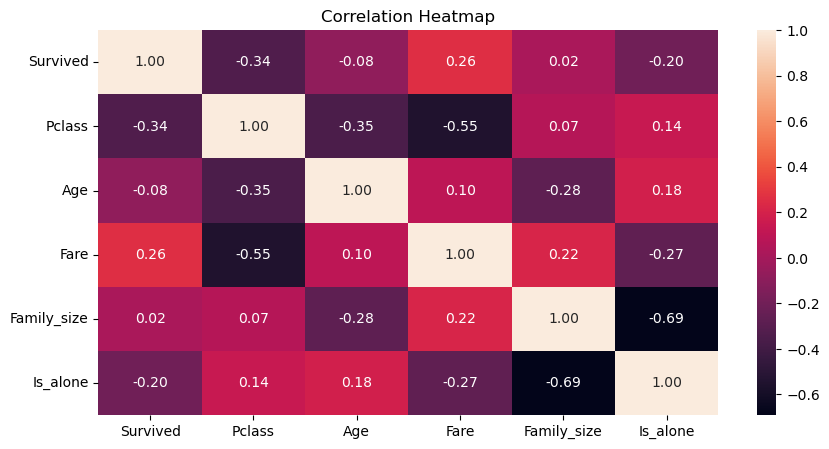

In [22]:
num_cols = df.select_dtypes(include=[np.number]).columns
plt.figure(figsize=(10,5))
sns.heatmap(df[num_cols].corr(), annot=True, fmt = '.2f')
plt.title("Correlation Heatmap")
plt.plot()

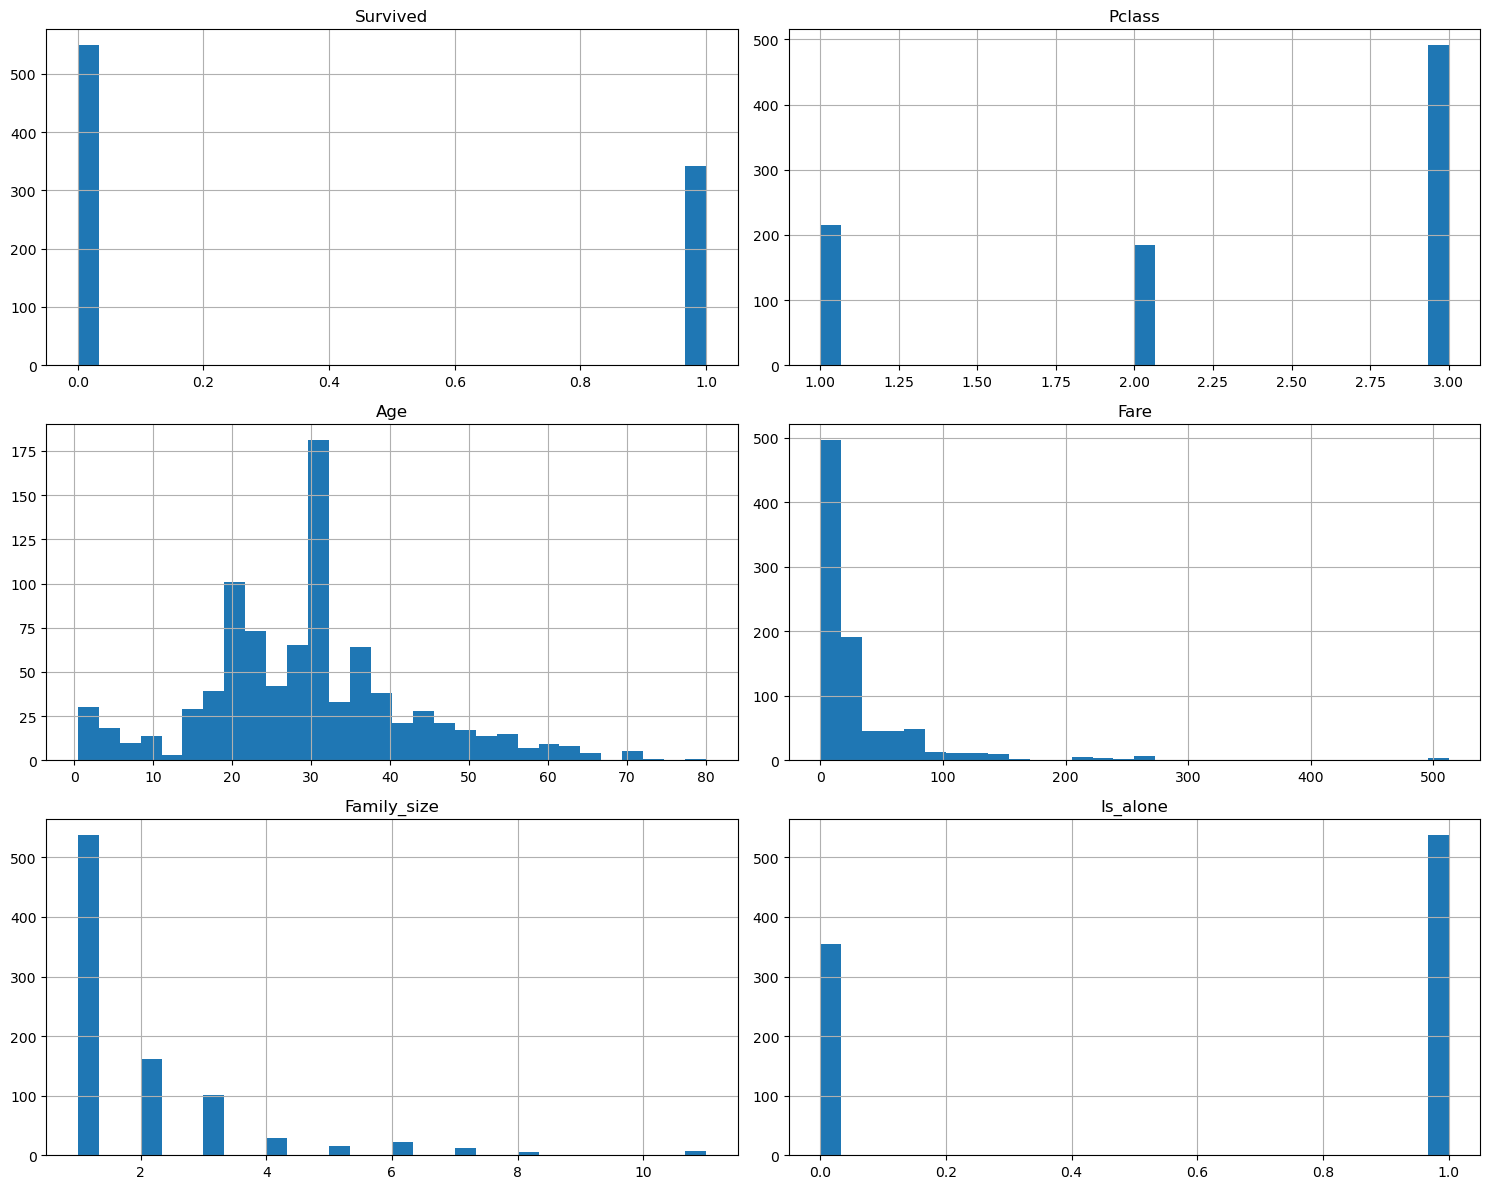

In [23]:
df.hist(figsize=(15,12),bins=30)
plt.tight_layout()
plt.show()

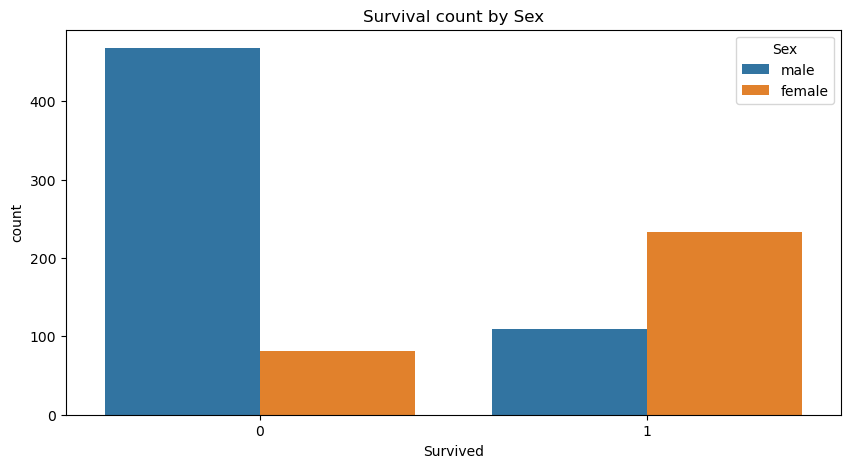

In [24]:
plt.figure(figsize=(10,5))
sns.countplot(x=df['Survived'], hue = df['Sex'])
plt.title("Survival count by Sex")
plt.show()

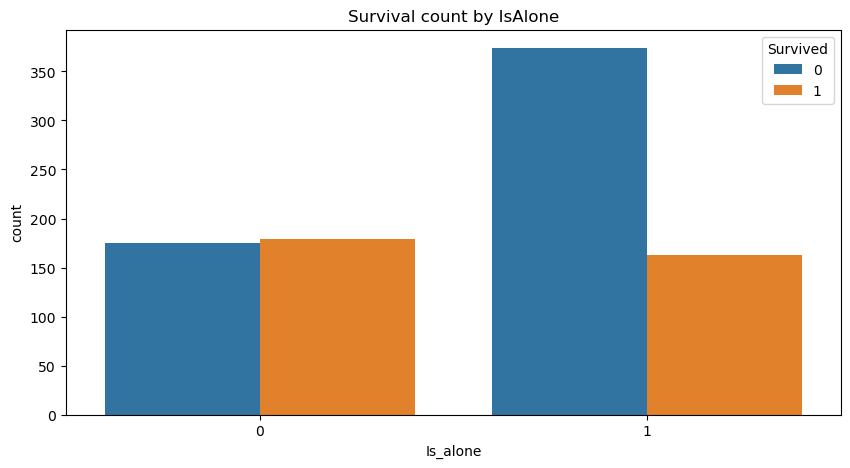

In [25]:
plt.figure(figsize=(10,5))
sns.countplot(x=df['Is_alone'], hue = df['Survived'])
plt.title("Survival count by IsAlone")
plt.show()

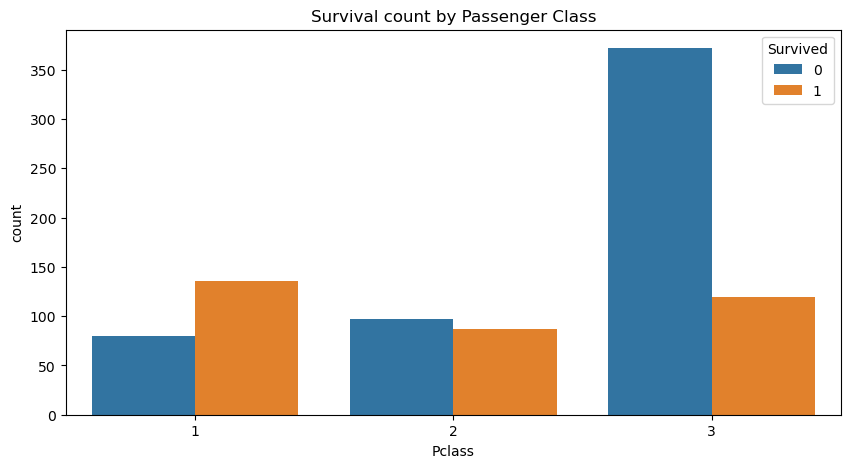

In [26]:
plt.figure(figsize=(10,5))
sns.countplot(x=df['Pclass'], hue= df['Survived'] )
plt.title("Survival count by Passenger Class")
plt.show()

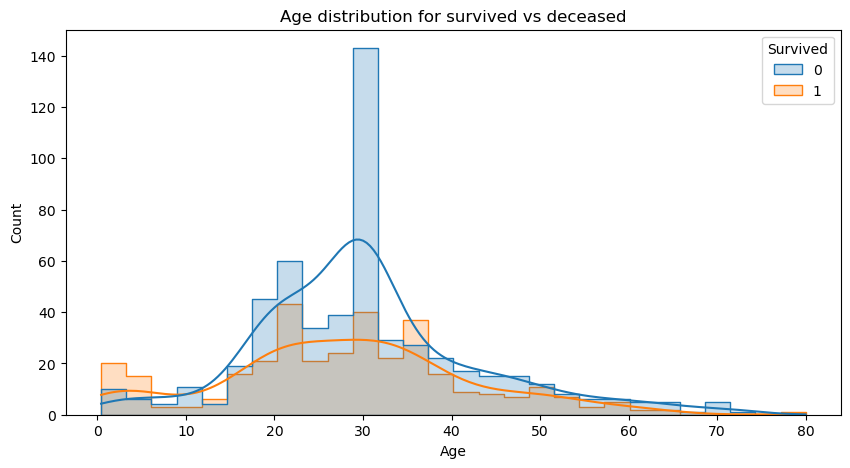

In [27]:
plt.figure(figsize=(10,5))
sns.histplot( x = df['Age'] , hue=df['Survived'], kde = True, element='step')
plt.title("Age distribution for survived vs deceased")
plt.show()

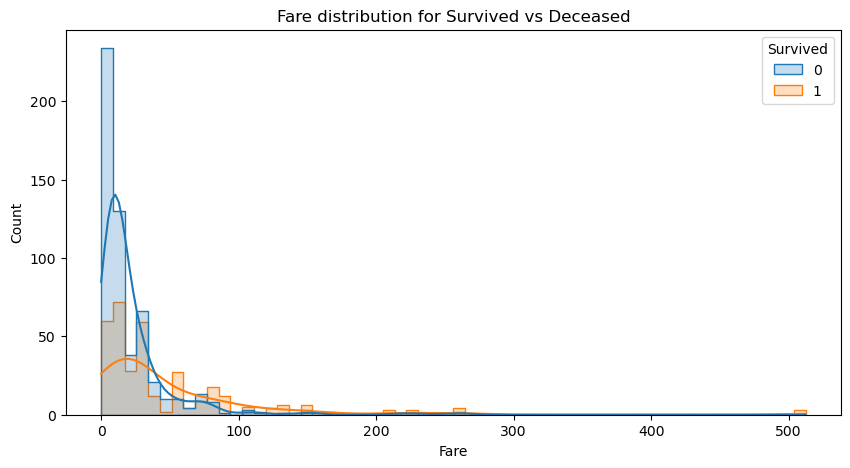

In [28]:
plt.figure(figsize=(10,5))
sns.histplot(x = df['Fare'], hue= df['Survived'], kde = True, element='step')
plt.title("Fare distribution for Survived vs Deceased")
plt.show()

# Modeling

In [29]:
# importing
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, roc_auc_score
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [30]:
X = df.drop('Survived', axis=1)
y = df['Survived']
X_train, X_test, y_train, y_test = train_test_split(X , y , test_size = 0.2 , random_state = 42, stratify=y)

In [31]:
num_cols = ['Age', 'Fare' , 'Family_size']
cat_cols = ['Pclass', 'Sex', 'Embarked', 'Title', 'Is_alone']

## Logistic Regression

In [32]:
preprocessor_lr = ColumnTransformer([
    ('cat', OneHotEncoder(drop='first'), cat_cols),
    ('num', StandardScaler(), num_cols)
])

In [35]:
model_lr = LogisticRegression(max_iter=1000)

In [ ]:
pipeline_lr = Pipeline([
    ('preprocessor', preprocessor_lr),
    ('model', model_lr)
])